## Testing GPUs

## **Phase 1: Algebra & Geometry Bridge**
### **Module 1: Variables, Equations, and the Balance Scale**

#### **1. The Supermarket Intuition**
Imagine a classic, two-pan balance scale sitting in the produce section. On the left pan, there is an unmarked, sealed box of apples, plus $2$ loose apples. On the right pan, there are $10$ loose apples. The scale is perfectly balanced. 

You don't know how many apples are in the box. But because the scale is balanced, you can use logic. If you remove $2$ loose apples from the left pan, the scale tips. To restore balance, you *must* remove exactly $2$ apples from the right pan. Now, the left pan only holds the box, and the right pan holds $8$ apples. The scale is balanced again. Therefore, the box must contain $8$ apples. 

This is the entire foundation of Algebra.

#### **2. Rigorous Theory: The State of Equality**
* **Variables:** A variable (usually $x, y, z$) is simply a placeholder for an unknown number. It behaves exactly like an integer or a rational number and follows all the axioms we proved in Phase 0 (Commutativity, Distributivity, etc.).
* **The Equation ($=$):** An equals sign does not mean "calculate the answer." It is a statement of fact: **The expression on the left has the exact same mathematical value as the expression on the right.** It is our perfectly balanced scale.
* **The Golden Rule of Algebra:** You can apply any valid mathematical operation to an equation, **provided you apply it equally to both the entire left side and the entire right side.** * If $A = B$, then $A + c = B + c$.
    * If $A = B$, then $A \times c = B \times c$.
* **Isolating the Variable:** The goal of solving an algebraic equation is to systematically "strip away" the known numbers surrounding your variable using inverse operations, maintaining the balance of the scale at every single step, until the variable stands completely alone.

#### **3. Step-by-Step Example**
Solve for $x$:  $3x + 5 = 17$
1.  Subtract $5$ from *both* sides: $3x + 5 - 5 = 17 - 5 \rightarrow 3x = 12$
2.  Divide *both* sides by $3$: $\frac{3x}{3} = \frac{12}{3} \rightarrow x = 4$

---

### **Pen-and-Paper Theory Exercises**
Please grab your notebook. To prove to me that you understand the "balance scale," I need you to **write down the algebraic operation you are performing on both sides at every step**. 

1.  **Easy:** Solve for $x$:  $4x - 7 = 13$
2.  **Medium:** Solve for $y$. Group the variables on one side and the constants on the other:  $5y + 3 = 2y - 9$
3.  **Hard:** Solve for $z$. You will need to use the distributive property first:  $2(z - 4) + 3z = 5(z + 1) - 13$
4.  **Advanced / Research:** Solve for $x$ in the equation: $\frac{a \cdot x + b}{c} = d$. Your final answer will not be a number, but a formula representing $x$ strictly in terms of the constants $a, b, c,$ and $d$. (Assume $a \neq 0$ and $c \neq 0$).

In [3]:
import torch
import tensorflow as tf

print("PyTorch MPS (GPU) available:", torch.backends.mps.is_available())
print("TensorFlow Version:", tf.__version__)
print("TensorFlow running on CPU:", len(tf.config.list_physical_devices('CPU')) > 0)

PyTorch MPS (GPU) available: True
TensorFlow Version: 2.21.0
TensorFlow running on CPU: True


In [4]:
tf.config.list_physical_devices('CPU')

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

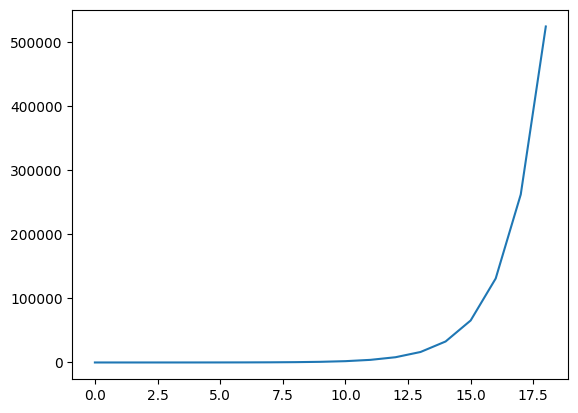

In [5]:
def compute_scaling(base, max_power):
    powers = []
    for i in range(1, max_power):
        powers.append(base ** i)
    return powers
powers = compute_scaling(2, 20)

import matplotlib.pyplot as plt
plt.plot(powers)


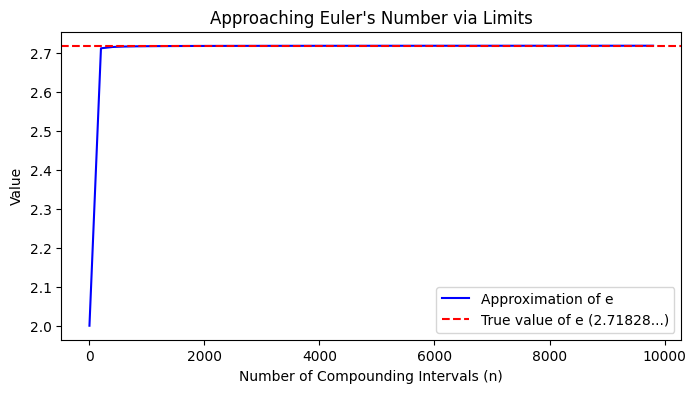

Final approximation of e at n=10000: 2.718143167730419


In [6]:
import matplotlib.pyplot as plt

def calculate_e_limit(max_n):
    # We will track the number of intervals (n) and the resulting value
    n_values = []
    e_approximations = []
    
    # We test larger and larger values of n (compounding more frequently)
    for n in range(1, max_n, max_n // 50):  # stepping through 50 points
        # The limit definition formula for e: (1 + 1/n)^n
        val = (1 + 1/n)**n 
        
        n_values.append(n)
        e_approximations.append(val)
        
    return n_values, e_approximations

# Calculate the limit as n approaches 10,000 intervals
n_vals, e_vals = calculate_e_limit(10000)

# Plot the results
plt.figure(figsize=(8, 4))
plt.plot(n_vals, e_vals, label="Approximation of e", color='blue')
plt.axhline(y=2.71828, color='red', linestyle='--', label="True value of e (2.71828...)")
plt.xlabel("Number of Compounding Intervals (n)")
plt.ylabel("Value")
plt.title("Approaching Euler's Number via Limits")
plt.legend()
plt.show()

# Print the final value
print(f"Final approximation of e at n=10000: {e_vals[-1]}")

### Phase 1 | Module 1: The Algebra & Geometry Bridge (Coordinate Geometry & Polynomials)

To build machine learning models, we have to translate the physical world into a mathematical space. We do this using Coordinate Geometry and Polynomials.

#### 1. Coordinate Geometry (The City Grid)

Imagine a perfectly flat city. To find any building, you need an East/West address (the $x$-axis) and a North/South address (the $y$-axis). This is the **Cartesian Plane**.

* **The Line ($y = mx + b$):** This is the fundamental equation of a straight line. 
    * $x$ and $y$ are your coordinates.
    * $m$ is the **slope** (how steep the line is: $\frac{\text{change in } y}{\text{change in } x}$).
    * $b$ is the **y-intercept** (where the line crosses the vertical axis).
* **The Distance Formula (Pythagoras applied):** If you are at point $A (x_1, y_1)$ and want to walk directly to point $B (x_2, y_2)$, the shortest distance $d$ is derived straight from the Pythagorean theorem ($a^2 + b^2 = c^2$):
    $$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

#### 2. Polynomials (The Language of Curves)
A straight line is a **1st-degree polynomial** (because $x$ is only raised to the power of 1). But the real world is curvy. 
A polynomial is simply an expression consisting of variables and coefficients, involving only addition, subtraction, multiplication, and non-negative integer exponents.

* **2nd-Degree (Quadratic):** $y = ax^2 + bx + c$. This creates a U-shaped curve called a parabola. The Loss Functions we optimize in Deep Learning are often massive, multi-dimensional parabolas!
* **Factoring:** This is the process of breaking a complex polynomial down into simpler, multipliable building blocks. For example, the quadratic $x^2 + 5x + 6$ can be factored into $(x + 2)(x + 3)$. 

---

### Your Next Action: Code & Theory Implementation

Since we are doing book+code first, here is your fully commented Python snippet. Please run this in your Jupyter Notebook to see how we plot these algebraic concepts from scratch.

```python
import numpy as np
import matplotlib.pyplot as plt

# 1. Coordinate Geometry: Defining a straight line (y = 2x + 1)
x_line = np.linspace(-10, 10, 100) # Create 100 points between -10 and 10
m = 2  # Slope
b = 1  # Y-intercept
y_line = m * x_line + b

# 2. Polynomials: Defining a quadratic curve (y = x^2 - 4x + 4)
x_poly = np.linspace(-5, 9, 100)
# We can express this polynomial either expanded or factored!
# Expanded: y = x**2 - 4*x + 4
# Factored: y = (x - 2)**2
y_poly = (x_poly - 2)**2 

# Plotting the mathematical spaces
plt.figure(figsize=(10, 5))

# Plot the Line
plt.subplot(1, 2, 1)
plt.plot(x_line, y_line, color='blue')
plt.title("Coordinate Geometry: y = 2x + 1")
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)

# Plot the Polynomial
plt.subplot(1, 2, 2)
plt.plot(x_poly, y_poly, color='red')
plt.title("Polynomial: y = (x - 2)^2")
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)

plt.tight_layout()
plt.show()
```

### Phase 1 | Module 1: Theory Exercises

Grab your pen and paper. No untaught terminology here—just rigorous algebra and geometry based strictly on what was defined above.

1.  **(Easy):** You are given two points on a Cartesian grid: $A(1, 2)$ and $B(4, 8)$. Calculate the slope ($m$) of the line that connects them.
2.  **(Medium):** Using the same two points $A(1, 2)$ and $B(4, 8)$, calculate the exact straight-line distance between them using the distance formula.
3.  **(Hard):** You are given a factored polynomial: $y = (x + 4)(x - 5)$. Expand this into its standard quadratic form ($y = ax^2 + bx + c$).
4.  **(Research/Extension):** We defined the 2D distance formula as $d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$. Based on logical algebraic scaling, what would the exact mathematical formula be to calculate the distance between two points in a **3-Dimensional** coordinate space $(x, y, z)$?

Run the code to visualize the math, solve the 4 theory problems, and share your answers! 

### Answers:
1. 2
2. 45**0.5
3. x**2 - x - 20
4. ((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2) ** 0.5

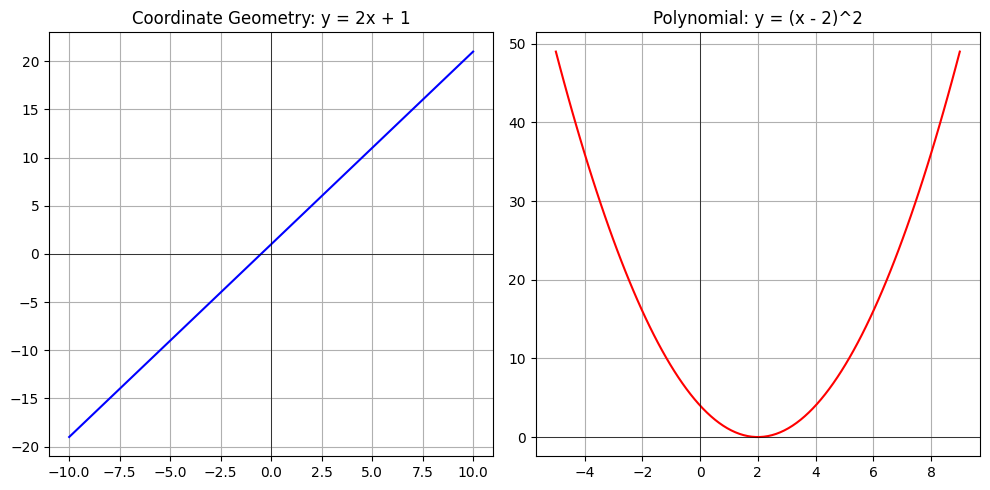

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Coordinate Geometry: Defining a straight line (y = 2x + 1)
x_line = np.linspace(-10, 10, 100) # Create 100 points between -10 and 10
m = 2  # Slope
b = 1  # Y-intercept
y_line = m * x_line + b

# 2. Polynomials: Defining a quadratic curve (y = x^2 - 4x + 4)
x_poly = np.linspace(-5, 9, 100)
# We can express this polynomial either expanded or factored!
# Expanded: y = x**2 - 4*x + 4
# Factored: y = (x - 2)**2
y_poly = (x_poly - 2)**2 

# Plotting the mathematical spaces
plt.figure(figsize=(10, 5))

# Plot the Line
plt.subplot(1, 2, 1)
plt.plot(x_line, y_line, color='blue')
plt.title("Coordinate Geometry: y = 2x + 1")
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)

# Plot the Polynomial
plt.subplot(1, 2, 2)
plt.plot(x_poly, y_poly, color='red')
plt.title("Polynomial: y = (x - 2)^2")
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)

plt.tight_layout()
plt.show()